# Numerisk derivasjon av $\ln Q$ i utregning av indre energi $U$

_Underveisoppgave der studenten må fylle inn kode selv_

[Partisjonsfunksjonen og molekylær energi](https://andreasdh.github.io/Bifrost/docs/partisjonsfunksjonen.html#partisjonsfunksjonen)

I denne oppgaven er systemet vårt et molekyl med to energinivåer: en grunntilstand med energi $E_0 = 0$ og en eksitert tilstand med energi $E_1 = \varepsilon$, der $\varepsilon = 5{.}0 \times 10^{-21}\ \text{J}$. Partisjonsfunksjonen blir dermed 

$Q = \sum_i e^{-E_i/k_BT} = e^{-0/k_BT} + e^{-\varepsilon/k_BT} = 1 + e^{-\varepsilon/k_BT}$

Du skal bruke sentraldifferansen til å estimere den indre energien $U = k_BT^2\,\frac{\partial \ln Q}{\partial T}$ numerisk ved temperaturene $T = 100, 200, 300, 500$ og $1000\ \text{K}$, og deretter plotte sammenhengen. Det skal gjøres i det påegynte Python-scriptet nedenfor.

**a)** Hva gjør funksjonene ``lnQ(T)`` og ``indre_energi(T, h=1e-3)``?

**b)** Lag en liste ``T`` med temperaturene, og en tom liste ``U`` som vi skal bruke til de indre energiene.

**c)** Lag en løkke som går over hver temperatur i ``T``. Skriv kode som gjør følgende for hver temperatur i løkka:

- Estimerer den indre energien for temperaturen ved bruk av ``indre_energi()``-funksjonen.

- Legger den indre energien til i ``U``

- Printer temperaturen med den indre energien som du estimerte pent, med enheter.

**d)** Plott indre energi mot temperatur. Husk tittel og aksetitler med enheter. Hva kan du si om sammenhengen mellom indre energi og temperatur?

**Utfordring**: Bruk formelen for $U$ ved partisjonsfunksjonen $Q$ og energiene $E_i$ til å finne grenseverdien til $U$ når $T \to \infty$. Hva betyr denne verdien?

In [371]:
import numpy as np
import matplotlib.pyplot as plt

kB = 1.38e-23   # Boltzmanns konstant, J/K
eps = 5.0e-21       # energigapet mellom nivåene, J

# Funksjon som tar den naturlige logaritmen av Q for to-nivåsystemet
def lnQ(T):
    return np.log(1 + np.exp(-eps/(kB*T)))

# Regner ut d(lnQ)/dT numerisk med sentraldifferansen (f(T+h) - f(T-h)) / (2h)
def indre_energi(T, h=1e-3):
    derivert = (lnQ(T + h) - lnQ(T - h)) / (2*h)
    return kB * T**2 * derivert

### SKRIV KODEN DIN HER ###

### Løsningsforslag

**a)** Dette gjør funksjonene:

- ``lnQ(T)``

Funksjonen tar en temperatur ``T`` og returnerer den naturlige logaritmen av partisjonsfunksjonen for verdien av ``T``. 

- ``indre_energi(T, h=1e-3)``

Funksjonen tar en temperatur ``T`` og en steglengde ``h``, og returnerer den indre energien ved ``T``. Den deriverte av ``lnQ`` regnes numerisk med sentraldifferansen, og ganges med ``kB * T**2`` etter formelen for indre energi.


**b)** Se Python-script.

**c)** Se Python-script.

**d)** Se Python-script for koden. 

**Utfordring**: Vi finner grenseverdien når temperaturen går mot uendelig:

$\lim_{T\to\infty} U = \lim_{T\to\infty} \frac{\varepsilon}{1 + e^{\varepsilon/k_BT}} = \frac{\varepsilon}{1 + e^0} = \frac{\varepsilon}{2}$

At grenseverdien er $\varepsilon/2$ betyr at de to nivåene ved svært høye temperaturer er tilnærmet like befolket: halvparten av molekylene ligger i grunntilstanden ($E=0$) og halvparten i det øvre nivået ($E=\varepsilon$), så gjennomsnittsenergien blir midt imellom.

T = 100 K: U = 1.300e-22 J
T = 200 K: U = 7.022e-22 J
T = 300 K: U = 1.151e-21 J
T = 500 K: U = 1.632e-21 J
T = 1000 K: U = 2.052e-21 J


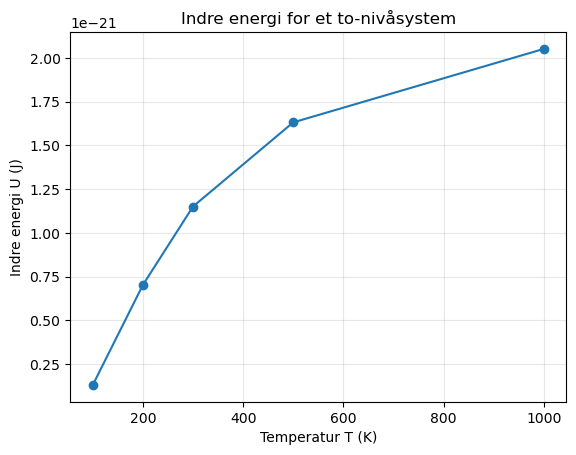

In [372]:
import numpy as np
import matplotlib.pyplot as plt

kB = 1.38e-23       # Boltzmanns konstant, J/K
eps = 5.0e-21       # energigapet mellom nivåene, J

# Funksjon som tar den naturlige logaritmen av Q for to-nivåsystemet
def lnQ(T):
    return np.log(1 + np.exp(-eps/(kB*T)))

# Regner ut d(lnQ)/dT numerisk med sentraldifferansen (f(T+h) - f(T-h)) / (2h)
def indre_energi(T, h=1e-3):
    derivert = (lnQ(T + h) - lnQ(T - h)) / (2*h)
    return kB * T**2 * derivert

### SKRIV KODEN DIN HER ###

# OPPGAVE B
T = [100, 200, 300, 500, 1000]   # Temperaturer i K
U = []                           # Tom liste til indre energier

# OPPGAVE C
for temp in T:
    u = indre_energi(temp)
    U.append(u)
    print(f"T = {temp} K: U = {u:.3e} J")

# OPPGAVE D
plt.plot(T, U, "-o")
plt.xlabel("Temperatur T (K)")
plt.ylabel("Indre energi U (J)")
plt.title("Indre energi for et to-nivåsystem")
plt.grid(alpha=0.3)
plt.show()

# Numerisk integrasjon med Trapesmetoden av Maxwell-Boltzmann-fordelingen

_Underveisoppgave der studenten må fylle inn kode selv_

Gasser

I denne oppgaven er systemet vårt en gass der molekylenes farter følger Maxwell-Boltzmann-fordelingen. For nitrogengass ($m = 4.65 \times 10^{-26}\ \text{kg}$) ved $T = 300\ \text{K}$ er fordelingen

$f(v) = 4\pi\left(\frac{m}{2\pi k_B T}\right)^{3/2} v^2 e^{-mv^2/2k_BT}$

Fordelingen er en sannsynlighetstetthet, og sannsynligheten for at et molekyl har fart mellom $v_1$ og $v_2$ er arealet under kurven mellom disse fartene:

$P(v_1 < v < v_2) = \int_{v_1}^{v_2} f(v)\, dv$

Du skal bruke trapesmetoden til å estimere denne sannsynligheten numerisk for farter mellom $v_1 = 400\ \text{m/s}$ og $v_2 = 800\ \text{m/s}$, og deretter plotte fordelingen med det aktuelle arealet skravert. Det skal gjøres i det påbegynte Python-scriptet nedenfor.

**a)** Lag en funksjon ``f(v)`` som regner ut Maxwell-Boltzmann-fordelingen for en gitt fart ``v``. Bruk konstantene ``kB``, ``m`` og ``T`` som er definert øverst i scriptet.

**b)** Lag en funksjon ``sannsynlighet(v1, v2)`` som tar to farter ``v1`` og ``v2`` som input og returnerer sannsynligheten for at et molekyl har fart mellom dem etter formelen ovenfor. Inne i funksjonen skal du:

- Lage et array med mange jevnt fordelte verdier mellom ``v1`` og ``v2`` med ``np.linspace``

- Bruke ``trapezoid`` til å regne ut arealet under ``f(v)`` mellom dem. 

- Returnere sannsynligheten.

**c)** Bruk ``sannsynlighet(v1, v2)`` til å regne ut sannsynligheten for fart mellom $400\ \text{m/s}$ og $800\ \text{m/s}$, og print svaret.

**d)** Bruk ``sannsynlighet(v1, v2)`` til å regne ut sannsynligheten for hele fartsområdet (fra $0$ til for eksempel $3000 \text{m/s}$). Hvilken verdi får sannsynligheten da, og hvorfor?

**Utfordring**:  Plott fordelingen ``f(v)`` for farter fra 0 til 1600 m/s, og bruk ``plt.fill_between`` til å skravere arealet mellom ``v1`` og ``v2``. Husk tittel og aksetitler med enheter. Hva forteller det skraverte arealet oss?


- [Dokumentasjon til ``trapezoid()``](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.trapezoid.html)

- [Dokumentasjon til ``plt.fill_between``](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.fill_between.html)


In [373]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid

kB = 1.380649e-23   # Boltzmanns konstant, J/K
m = 4.65e-26        # masse av et N2-molekyl, kg
T = 300             # temperatur, K

### SKRIV KODEN DIN HER ###

### Løsningsforslag

**a)** Se Python-script.

**b)** Se Python-script.

**c)** Se Python-script.

**d)** Se Python-script. Sannsynligheten blir tilnærmet 1, fordi molekylet med sikkerhet har en fart et sted i dette området — arealet under hele Maxwell-Boltzmann-kurven er alltid 1 siden fordelingen er normalisert. Ved å velge en verdi som er tilstrekkelig stor, som $3000 \text{ m/s}$, blir arealet tilnærmet lik 1.

**Utfordring**: Se Python-script. Det skraverte arealet er lik $0.550$ og forteller oss at sannsynligheten for at et molekyl har en fart mellom $400\ \text{m/s}$ og $800\ \text{m/s}$, er omtrent. $55\%$

P(400 < v < 800) = 0.5495
P(0 < v < 3000) = 1.0000


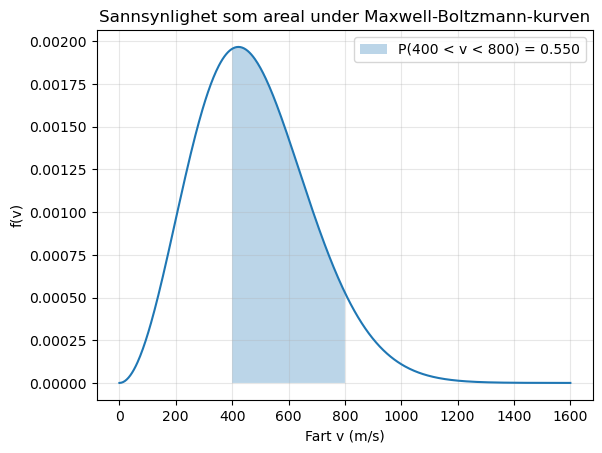

In [374]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid

kB = 1.380649e-23   # Boltzmanns konstant, J/K
m = 4.65e-26        # masse av et N2-molekyl, kg
T = 300             # temperatur, K

### SKRIV KODEN DIN HER ###

# OPPGAVE A
def f(v):
    return 4*np.pi * (m/(2*np.pi*kB*T))**1.5 * v**2 * np.exp(-m*v**2/(2*kB*T))

# OPPGAVE B
def sannsynlighet(v1, v2):
    v = np.linspace(v1, v2, 1000)
    return trapezoid(f(v), v)

# OPPGAVE C
v1 = 400
v2 = 800
P = sannsynlighet(v1, v2)
print(f"P({v1} < v < {v2}) = {P:.4f}")

# OPPGAVE D
print(f"P(0 < v < 3000) = {sannsynlighet(0,3000):.4f}")

# Utfordring
v = np.linspace(v1, v2, 1000)           # fartsverdiene i intervallet, til skraveringen
v_full = np.linspace(0, 1600, 500)
plt.plot(v_full, f(v_full))
plt.fill_between(v, f(v), alpha=0.3, label=f"P({v1} < v < {v2}) = {P:.3f}")
plt.xlabel("Fart v (m/s)")
plt.ylabel("f(v)")
plt.title("Sannsynlighet som areal under Maxwell-Boltzmann-kurven")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# De tre "typiske" hastighetene illustrert på et Maxwell-Boltzmann-plott

_Eksempel_

Gasser

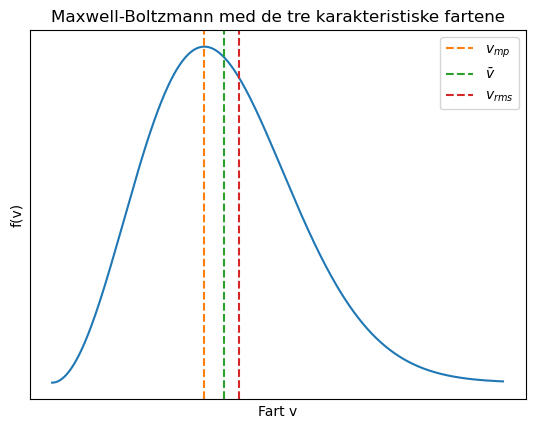

In [375]:
import numpy as np
import matplotlib.pyplot as plt

kB = 1.380649e-23   # Boltzmanns konstant, J/K
m = 4.65e-26        # masse av et N2-molekyl, kg
T = 1200            # temperatur, K (høy -> bred kurve)

# Maxwell-Boltzmann fartsfordeling
def f(v):
    return 4*np.pi * (m/(2*np.pi*kB*T))**1.5 * v**2 * np.exp(-m*v**2/(2*kB*T))

# De tre karakteristiske fartene
v_mp = np.sqrt(2*kB*T/m)              # mest sannsynlige fart
v_snitt = np.sqrt(8*kB*T/(np.pi*m))   # gjennomsnittsfart
v_rms = np.sqrt(3*kB*T/m)             # RMS-fart

# Plott kurven med de tre fartene markert
v = np.linspace(0, 2500, 500)
plt.plot(v, f(v))
plt.axvline(v_mp, color="C1", linestyle="--", label="$v_{mp}$")
plt.axvline(v_snitt, color="C2", linestyle="--", label="$\\bar{v}$")
plt.axvline(v_rms, color="C3", linestyle="--", label="$v_{rms}$")
plt.xlabel("Fart v")
plt.ylabel("f(v)")
plt.title("Maxwell-Boltzmann med de tre karakteristiske fartene")
plt.xticks([])
plt.yticks([])
plt.legend()
plt.show()

# En irreversibel ekspansjon nærmer seg en reversibel ekspansjon når vi deler inn i flre og flere trinn

_Eksempel_

Gasser

En ideell gass ($n = 1.0\ \text{mol}$) ekspanderer isotermt ved $T = 298\ \text{K}$ fra $V_i = 1.0\ \text{L}$ til $V_f = 3.0\ \text{L}$. Arbeidet er $w = -\int P\,dV$. Ved en irreversibel ekspansjon mot konstant ytre trykk gjøres det mindre arbeid enn ved en reversibel, fordi gassen bare "presser mot" et lavt ytre trykk hele veien. Vi kan dele ekspansjonen i flere trinn, der det ytre trykket settes ned litt for hvert trinn. Vi skal regne ut det totale arbeidet for $1, 2, 4, 8, \dots$ trinn, og se at det nærmer seg det reversible arbeidet $w_{rev} = -nRT\ln(V_f/V_i)$ når antall trinn øker. En reversibel prosess er nettopp grensen med uendelig mange små trinn.

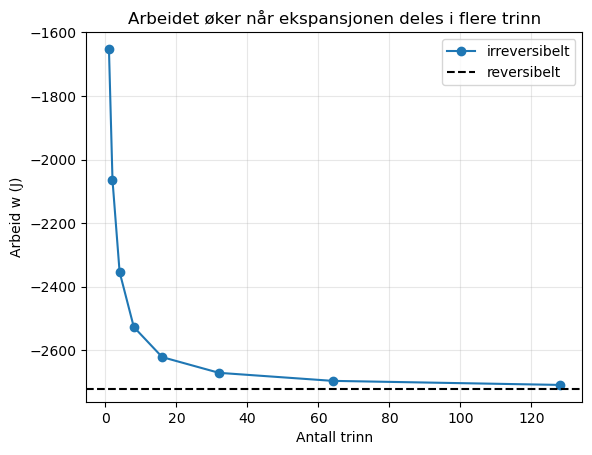

In [376]:
import numpy as np
import matplotlib.pyplot as plt

R = 8.314      # gasskonstanten, J/(mol K)
n = 1.0        # stoffmengde, mol
T = 298        # temperatur, K
Vi = 1.0e-3    # startvolum, m^3
Vf = 3.0e-3    # sluttvolum, m^3

# Gassens trykk (ideell gasslov)
def P(V):
    return n*R*T/V

# Regner ut irreversibelt arbeid for et gitt antall trinn
# I hvert trinn ekspanderer gassen mot konstant ytre trykk lik gassens trykk ved slutten av trinnet
def arbeid_trinn(n_trinn):
    kanter = np.linspace(Vi, Vf, n_trinn + 1)
    w = 0
    for i in range(n_trinn):
        P_ex = P(kanter[i+1])                 # ytre trykk i dette trinnet
        w += -P_ex*(kanter[i+1] - kanter[i])  # arbeid i dette trinnet
    return w

# Reversibelt arbeid (grensen med uendelig mange trinn)
w_rev = -n*R*T*np.log(Vf/Vi)

# Regn ut arbeidet for stadig flere trinn
trinn = [1, 2, 4, 8, 16, 32, 64, 128]
w_liste = []
for n_trinn in trinn:
    w = arbeid_trinn(n_trinn)
    w_liste.append(w)

# Plott: arbeidet som funksjon av antall trinn i integrasjonen
plt.plot(trinn, w_liste, "o-", label="irreversibelt")
plt.axhline(w_rev, color="k", linestyle="--", label="reversibelt")
plt.xlabel("Antall trinn")
plt.ylabel("Arbeid w (J)")
plt.title("Arbeidet øker når ekspansjonen deles i flere trinn")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Damptrykkurven for vann beregnet fra Clausius–Clapeyrons likning

_Eksempel_

Faser

Damptrykket til en væske øker med temperaturen ifølge Clausius-Clapeyrons likning

$P = P^* e^{-\chi}$
der 

$\chi = \frac{\Delta_{vap}H}{R}\left(\frac{1}{T} - \frac{1}{T^*}\right)$

For vann er $\Delta_{vap}H = 40.7\ \text{kJ/mol}$, med referansepunktet $T^* = 373.15\ \text{K}$ og $P^* = 1.013 \times 10^5\ \text{Pa}$. Vi skal regne ut damptrykket over et temperaturintervall og plotte kurven $P(T)$, og se at den treffer 1 atm ved kokepunktet.

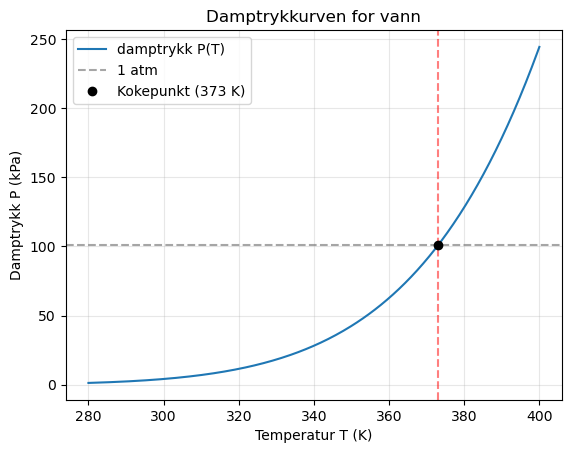

In [377]:
import numpy as np
import matplotlib.pyplot as plt

R = 8.314          # gasskonstanten, J/(mol K)
dHvap = 40.7e3     # fordampningsentalpi for vann, J/mol
Tstar = 373.15     # referansetemperatur (kokepunkt ved 1 atm), K
Pstar = 1.013e5    # damptrykk ved Tstar, Pa

# Clausius-Clapeyron: P = P* exp(-chi), chi = (dHvap/R)(1/T - 1/T*)
def P(T):
    chi = dHvap/R * (1/T - 1/Tstar)
    return Pstar*np.exp(-chi)

# Regn ut damptrykket over et temperaturintervall
T = np.linspace(280, 400, 300)
damptrykk = P(T)

atm = 1.013e5      # 1 atm i Pa

# Plott kurven, og marker 1 atm og kokepunktet
plt.plot(T, damptrykk/1000, label="damptrykk P(T)")
plt.axhline(atm/1000, color="gray", linestyle="--", alpha=0.7, label="1 atm")
plt.axvline(Tstar, color="red", linestyle="--", alpha=0.5)
plt.plot(Tstar, atm/1000, "ko", label="Kokepunkt (373 K)")
plt.xlabel("Temperatur T (K)")
plt.ylabel("Damptrykk P (kPa)")
plt.title("Damptrykkurven for vann")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Bestemmelse av fordampningsentalpi fra damptrykksmålinger ved lineær tilpasning av Clausius–Clapeyron

_Eksempel_

Faser

Damptrykket til en væske er målt ved fire temperaturer: ved $T = 300, 320, 340$ og $360\ \text{K}$ er trykket henholdsvis $3.5, 10.5, 27.0$ og $62.0\ \text{kPa}$. På logaritmisk form er Clausius-Clapeyrons likning en rett linje

$\ln P = -\frac{\Delta_{vap}H}{R}\cdot\frac{1}{T} + \text{konstant}$

Vi kan plotte $\ln P$ mot $1/T$, tilpasse en rett linje til punktene, og finne fordampningsentalpien direkte fra stigningstallet $\Delta_{vap}H$ fra stigningstallet.

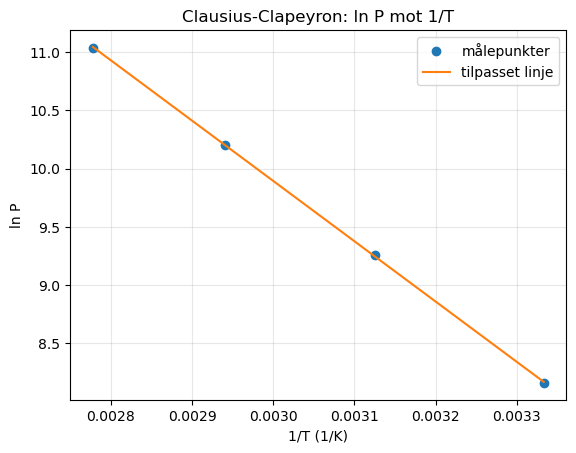

In [378]:
import numpy as np
import matplotlib.pyplot as plt

R = 8.314   # gasskonstanten, J/(mol K)

# Målt damptrykk ved noen temperaturer
Tdata = np.array([300, 320, 340, 360])      # K
Pdata = np.array([3.5e3, 10.5e3, 27.0e3, 62.0e3])  # Pa

# Clausius-Clapeyron på lineær form: ln P = -(dHvap/R)(1/T) + konstant
x = 1/Tdata
y = np.log(Pdata)
slope, intercept = np.polyfit(x, y, 1)

# Fordampningsentalpi fra stigningstallet
dHvap = -slope*R

plt.plot(x, y, "o", label="målepunkter")
plt.plot(x, slope*x + intercept, label="tilpasset linje")
plt.xlabel("1/T (1/K)")
plt.ylabel("ln P")
plt.title("Clausius-Clapeyron: ln P mot 1/T")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Bestemmelse av standard reaksjonsentalpi fra likevektskonstantens temperaturavhengighet ved lineær tilpasning av van 't Hoff-likningen

Likevektskonstanten $K$ til en reaksjon er målt ved fire temperaturer: ved $T = 298, 320, 340$ og $360\ \text{K}$ er $K$ henholdsvis $5.8 \times 10^5, 8.0 \times 10^4, 1.6 \times 10^4$ og $4.0 \times 10^3$. På integrert form er van 't Hoff-likningen en rett linje: $\ln K = -\frac{\Delta_r H^\circ}{R}\cdot\frac{1}{T} + \text{konstant}$. Vi skal plotte $\ln K$ mot $1/T$, tilpasse en rett linje, og finne standard reaksjonsentalpi $\Delta_r H^\circ$ fra stigningstallet.

drH = -71.7 kJ/mol


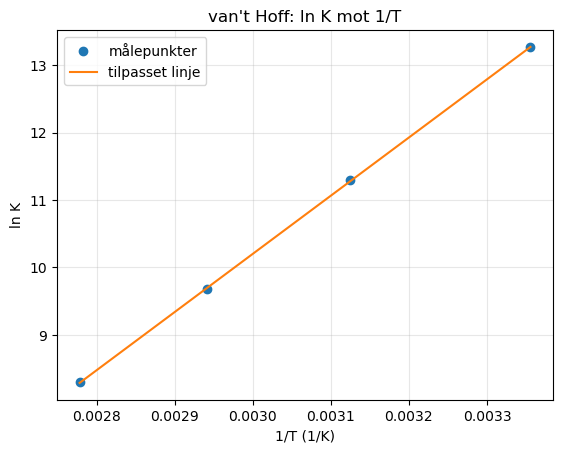

In [379]:
import numpy as np
import matplotlib.pyplot as plt

R = 8.314   # gasskonstanten, J/(mol K)

# Målt likevektskonstant ved noen temperaturer
Tdata = np.array([298, 320, 340, 360])           # K
Kdata = np.array([5.8e5, 8.0e4, 1.6e4, 4.0e3])    # dimensjonsløs

# van't Hoff på lineær form: ln K = -(drH/R)(1/T) + konstant
x = 1/Tdata
y = np.log(Kdata)
slope, intercept = np.polyfit(x, y, 1)

# Reaksjonsentalpi fra stigningstallet
drH = -slope*R
print(f"drH = {drH/1000:.1f} kJ/mol")

plt.plot(x, y, "o", label="målepunkter")
plt.plot(x, slope*x + intercept, label="tilpasset linje")
plt.xlabel("1/T (1/K)")
plt.ylabel("ln K")
plt.title("van't Hoff: ln K mot 1/T")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Numerisk bestemmelse av likevektssammensetningen ved å finne nullpunktet til reaksjonens Gibbs-energi

For reaksjonen $A \rightleftharpoons B$ lar vi $\xi$ være ekstenten (hvor langt reaksjonen har gått fra rent A). Da er aktivitetene $a_A = 1 - \xi$ og $a_B = \xi$, og reaksjonskvotienten blir

$Q = \frac{a_B}{a_A} = \frac{\xi}{1 - \xi}.$

Reaksjonsisotermen gir reaksjonens Gibbs-energi som funksjon av sammensetningen:

$\Delta_r G = \Delta_r G^\circ + RT\ln Q,$

der $\Delta_r G^\circ = -RT\ln K$. Systemet er i likevekt der $\Delta_r G = 0$, altså der det ikke er noen netto drivkraft i noen retning. Vi skal finne denne likevektsekstenten numerisk ved å formulere $\Delta_r G(\xi) = 0$ som et nullpunktsproblem og løse det med halveringsmetoden, for en reaksjon med $K = 4.0$ ved $T = 298\ \text{K}$. Til slutt sammenligner vi med den analytiske likevekten $\xi = \frac{K}{1+K}$.

xi ved likevekt (numerisk) = 0.800
xi analytisk K/(1+K)       = 0.800


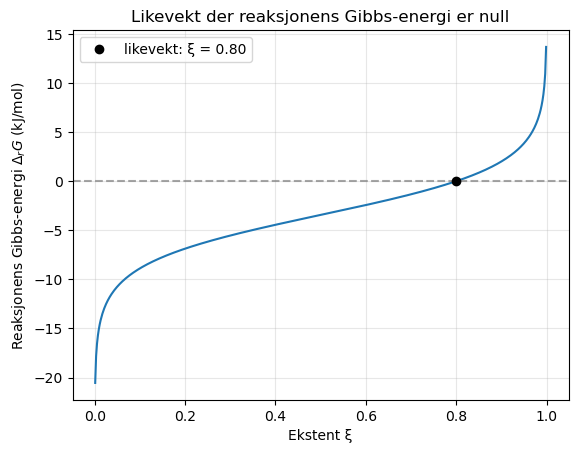

In [380]:
import numpy as np
import matplotlib.pyplot as plt

R = 8.314   # gasskonstanten, J/(mol K)
T = 298     # temperatur, K
K = 4.0     # likevektskonstant

# Standard reaksjons-Gibbs-energi fra likevektskonstanten
drG0 = -R*T*np.log(K)

# Reaksjonens Gibbs-energi som funksjon av ekstenten xi.
# For A <-> B er Q = xi/(1-xi), og drG = drG0 + RT ln Q.
def drG(xi):
    Q = xi/(1-xi)
    return drG0 + R*T*np.log(Q)

# Halveringsmetoden finner nullpunktet til en funksjon
def halveringsmetoden(f, a, b, tol=1E-10, maks_iterasjoner=100):
    m = (a + b)/2
    i = 0
    while i < maks_iterasjoner and abs(f(m)) > tol:
        if f(a)*f(m) < 0:
            b = m
        else:
            a = m
        m = (a + b)/2
        i += 1
    return m

# Likevekt er der drG = 0
xi_eq = halveringsmetoden(drG, 0.001, 0.999)

print(f"xi ved likevekt (numerisk) = {xi_eq:.3f}")
print(f"xi analytisk K/(1+K)       = {K/(1+K):.3f}")

# Plott drG mot xi og marker nullpunktet
xi = np.linspace(0.001, 0.999, 500)
plt.plot(xi, drG(xi)/1000)
plt.axhline(0, color="gray", linestyle="--", alpha=0.7)
plt.plot(xi_eq, 0, "ko", label=f"likevekt: ξ = {xi_eq:.2f}")
plt.xlabel("Ekstent ξ")
plt.ylabel("Reaksjonens Gibbs-energi $\\Delta_r G$ (kJ/mol)")
plt.title("Likevekt der reaksjonens Gibbs-energi er null")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Del 1: Kinetikk - Numerisk løsning av hastighetsloven for første orden med Eulers metode og sammenligning med den eksakte integrerte loven

_Oppgave_

Kinetikk

En hastighetslov er en differensiallikning: for en førsteordens reaksjon $A \rightarrow$ produkter er

$\frac{d[A]}{dt} = -k_r[A]$

Vi skal løse denne numerisk med Eulers metode, som tar små steg framover i tid. Hvis vi kjenner konsentrasjonen $[A]$ akkurat nå, kan vi regne ut konsentrasjonen et lite tidssteg $\Delta t$ senere slik:

$[A]_{ny} = [A] + \frac{d[A]}{dt}\cdot\Delta t$

Vi bruker $k_r = 0.3\ \text{s}^{-1}$ og $[A]_0 = 1.0\ \text{mol/L}$, og skal til slutt sammenligne den numeriske løsningen med den eksakte integrerte loven $[A] = [A]_0 e^{-k_r t}$. Det skal gjøres i det påbegynte Python-scriptet nedenfor.

**a)** Lag to tomme lister ``t_liste`` og ``A_liste`` som vi skal fylle med tid og konsentrasjon underveis. Lag også variablene ``t = 0`` (starttid) og ``A = A0`` (startkonsentrasjon).

**b)** Lag en løkke over ``N`` steg. For hvert steg skal du:

- Legge ``t`` til i ``t_liste`` og ``A`` til i ``A_liste``.

- Regne ut den deriverte for konsentrasjonen akkurat nå.

- Oppdatere konsentrasjonen med ett Euler-steg.

- Oppdatere tiden.

**c)** Plott den numeriske løsningen (``A_liste`` mot ``t_liste``). Husk tittel og aksetitler med enheter.

**d)** Legg til den eksakte løsningen $[A] = [A]_0 e^{-k_r t}$ i samme plott, med en stiplet linje. Hvor godt stemmer Euler-løsningen med den eksakte?

In [381]:
import numpy as np
import matplotlib.pyplot as plt

kr = 0.3       # hastighetskonstant, 1/s
A0 = 1.0       # startkonsentrasjon, mol/L
dt = 0.01      # tidssteg, s
N = 1000       # antall steg

### SKRIV KODEN DIN HER ###

### Løsningsforslag

**a)** Se Python-script.

**b)** Se Python-script.

**c)** Se Python-script.

**d)** Se Python-script. 

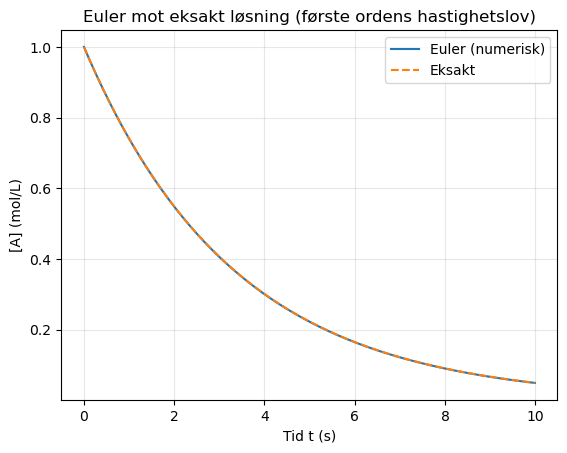

In [382]:
import numpy as np
import matplotlib.pyplot as plt

kr = 0.3       # hastighetskonstant, 1/s
A0 = 1.0       # startkonsentrasjon, mol/L
dt = 0.01      # tidssteg, s
N = 1000       # antall steg

### SKRIV KODEN DIN HER ###

# OPPGAVE A
t_liste = []
A_liste = []
t = 0
A = A0

# OPPGAVE B
for i in range(N):
    t_liste.append(t)
    A_liste.append(A)
    dAdt = -kr*A               # hastighetsloven
    A = A + dAdt*dt            # ett Euler-steg
    t = t + dt

# OPPGAVE C
plt.plot(t_liste, A_liste, label="Euler (numerisk)")

# OPPGAVE D
t_arr = np.array(t_liste)
plt.plot(t_arr, A0*np.exp(-kr*t_arr), "--", label="Eksakt")

plt.xlabel("Tid t (s)")
plt.ylabel("[A] (mol/L)")
plt.title("Euler mot eksakt løsning (første ordens hastighetslov)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Numerisk simulering av reaksjonsmekanismen A → I → P og visualisering av mellomproduktets forløp

_Eksempel_



En reaksjon som går via et mellomprodukt, $A \rightarrow I \rightarrow P$, beskrives av tre koblede differensiallikninger: 
$\frac{d[A]}{dt} = -k_1[A]$ 

$\frac{d[I]}{dt} = k_1[A] - k_2[I]$ 

$\frac{d[P]}{dt} = k_2[I]$

Vi skal løse dem samtidig med Eulers metode ($k_1 = 1.0\ \text{s}^{-1}$, $k_2 = 0.5\ \text{s}^{-1}$, $[A]_0 = 1.0\ \text{mol/L}$) og plotte hvordan de tre konsentrasjonene utvikler seg.

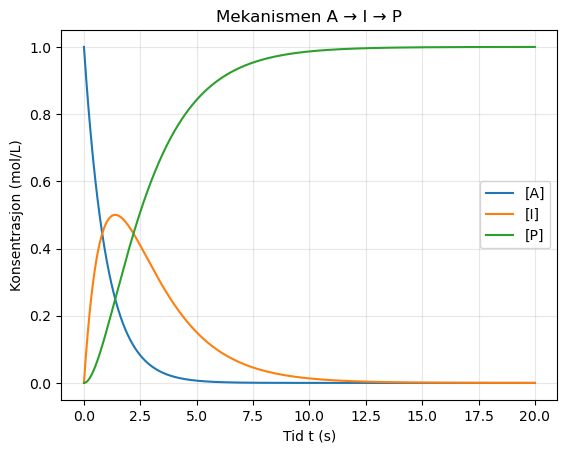

In [383]:
import numpy as np
import matplotlib.pyplot as plt

k1 = 1.0       # A -> I, 1/s
k2 = 0.5       # I -> P, 1/s
dt = 0.001     # tidssteg, s
N = 20000      # antall steg

A = 1.0        # startkonsentrasjoner, mol/L
I = 0.0
P = 0.0

t_liste = []; A_liste = []; I_liste = []; P_liste = []
t = 0
for i in range(N):
    t_liste.append(t); A_liste.append(A); I_liste.append(I); P_liste.append(P)
    # de tre hastighetslovene
    dA = -k1*A
    dI = k1*A - k2*I
    dP = k2*I
    # ett Euler-steg for hver
    A = A + dA*dt
    I = I + dI*dt
    P = P + dP*dt
    t = t + dt

plt.plot(t_liste, A_liste, label="[A]")
plt.plot(t_liste, I_liste, label="[I]")
plt.plot(t_liste, P_liste, label="[P]")
plt.xlabel("Tid t (s)")
plt.ylabel("Konsentrasjon (mol/L)")
plt.title("Mekanismen A → I → P")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Del 2: Kinetikk - Numerisk bestemmelse av halveringstiden ved å løse konsentrasjonslikningen som et nullpunktsproblem

_Oppgave_

Kinetikk

En hastighetslov er en differensiallikning: for en førsteordens reaksjon $A \rightarrow$ produkter er

$\frac{d[A]}{dt} = -k_r[A]$

Vi skal løse denne numerisk med Eulers metode, som tar små steg framover i tid. Hvis vi kjenner konsentrasjonen $[A]$ akkurat nå, kan vi regne ut konsentrasjonen et lite tidssteg $\Delta t$ senere slik:

$[A]_{ny} = [A] + \frac{d[A]}{dt}\cdot\Delta t$

Vi bruker $k_r = 0.3\ \text{s}^{-1}$ og $[A]_0 = 1.0\ \text{mol/L}$, og skal sammenligne den numeriske løsningen med den eksakte integrerte loven $[A] = [A]_0 e^{-k_r t}$. Det skal gjøres i det påbegynte Python-scriptet nedenfor.

**a)** Lag to tomme lister ``t_liste`` og ``A_liste`` som vi skal fylle med tid og konsentrasjon underveis. Lag også variablene ``t = 0`` (starttid) og ``A = A0`` (startkonsentrasjon).

**b)** Lag en løkke som går ``N`` steg framover i tid. For hvert steg skal du:

- Legge ``t`` til i ``t_liste`` og ``A`` til i ``A_liste``.

- Regne ut den deriverte $\frac{d[A]}{dt} = -k_r[A]$ for konsentrasjonen akkurat nå.

- Oppdatere konsentrasjonen med ett Euler-steg: $[A]_{ny} = [A] + \frac{d[A]}{dt}\cdot\Delta t$.

- Oppdatere tiden: $t_{ny} = t + \Delta t$.

**c)** Plott den numeriske løsningen (``A_liste`` mot ``t_liste``). Husk tittel og aksetitler med enheter.

**d)** Legg til den eksakte løsningen $[A] = [A]_0 e^{-k_r t}$ i samme plott, med en stiplet linje. Hvor godt stemmer Euler-løsningen med den eksakte?

**e)** Nå skal vi undersøke hvordan tidssteget påvirker nøyaktigheten. Lag en løkke som prøver flere ulike tidssteg, for eksempel ``dt = 0.01``, ``1.0`` og ``3.0``, og plott Euler-løsningen for hver av dem i samme figur sammen med den eksakte løsningen. Her er det viktig å holde **sluttiden fast** (for eksempel 15 sekunder), slik at alle kurvene dekker det samme tidsrommet. Antall steg må da regnes ut fra tidssteget: ``N = int(T_slutt/dt)``. Hva skjer med Euler-løsningen når tidssteget blir større, og hva forteller det deg om avveiningen mellom nøyaktighet og antall steg?

In [384]:
import numpy as np
import matplotlib.pyplot as plt

kr = 0.3       # hastighetskonstant, 1/s
A0 = 1.0       # startkonsentrasjon, mol/L
dt = 0.01      # tidssteg, s
N = 1000       # antall steg

### SKRIV KODEN DIN HER ###

### Løsningsforslag

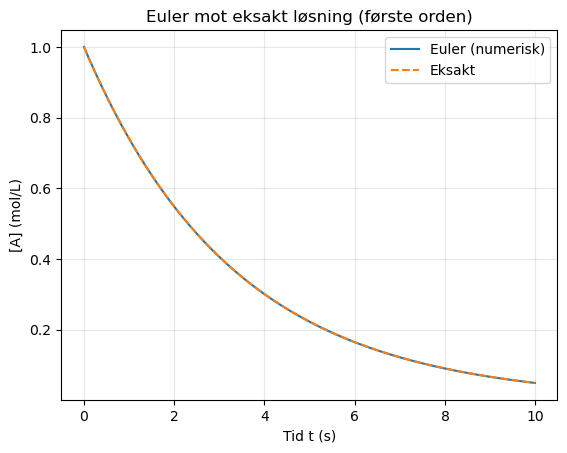

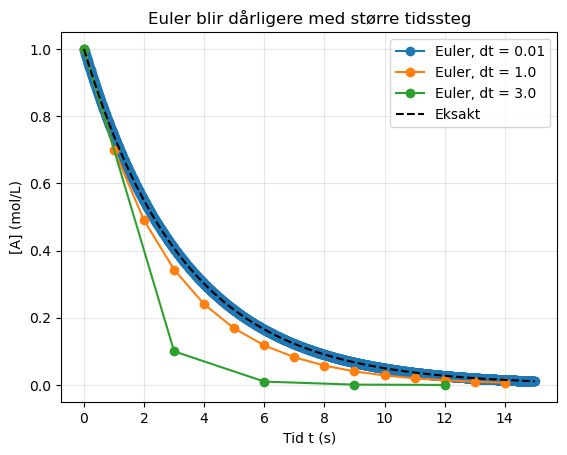

In [385]:
import numpy as np
import matplotlib.pyplot as plt

kr = 0.3       # hastighetskonstant, 1/s
A0 = 1.0       # startkonsentrasjon, mol/L
dt = 0.01      # tidssteg, s
N = 1000       # antall steg

### SKRIV KODEN DIN HER ###

# OPPGAVE A
t_liste = []
A_liste = []
t = 0
A = A0

# OPPGAVE B
for i in range(N):
    t_liste.append(t)
    A_liste.append(A)
    dAdt = -kr*A               # hastighetsloven
    A = A + dAdt*dt            # ett Euler-steg
    t = t + dt

# OPPGAVE C
plt.plot(t_liste, A_liste, label="Euler (numerisk)")

# OPPGAVE D
t_arr = np.array(t_liste)
plt.plot(t_arr, A0*np.exp(-kr*t_arr), "--", label="Eksakt")
plt.xlabel("Tid t (s)")
plt.ylabel("[A] (mol/L)")
plt.title("Euler mot eksakt løsning (første orden)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# OPPGAVE E
T_slutt = 15.0
for dt in [0.01, 1.0, 3.0]:
    N = int(T_slutt/dt)
    t_liste = []
    A_liste = []
    t = 0
    A = A0
    for i in range(N):
        t_liste.append(t)
        A_liste.append(A)
        A = A + (-kr*A)*dt
        t = t + dt
    plt.plot(t_liste, A_liste, "o-", label=f"Euler, dt = {dt}")

t_arr = np.linspace(0, T_slutt, 500)
plt.plot(t_arr, A0*np.exp(-kr*t_arr), "k--", label="Eksakt")
plt.xlabel("Tid t (s)")
plt.ylabel("[A] (mol/L)")
plt.title("Euler blir dårligere med større tidssteg")
plt.legend()
plt.grid(alpha=0.3)
plt.show()